In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree
import math #### все функции
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve
from IPython.display import display, HTML
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier

from sympy import *

import mpl_toolkits.mplot3d as p3
import random
import time


from functools import partial
#from ipywidgets import interact, RadioButtons, IntSlider, FloatSlider, Dropdown, BoundedFloatText
from numpy.linalg import norm

from scipy import sparse

random.seed(42) # начальное состояние генератора случайных чисел, чтобы можно было воспроизводить результаты.

#!unzip «путь_до_архива»
#Всё извлечётся в память Colab.

In [2]:
import plotly.express as px
import statsmodels.api as sm


In [13]:
from etna.datasets.tsdataset import TSDataset
from etna.analysis import acf_plot
from etna.analysis import plot_correlation_matrix
from etna.transforms import LagTransform
from etna.transforms import LinearTrendTransform
from etna.analysis import acf_plot
from etna.analysis import plot_correlation_matrix
from etna.analysis import plot_trend
from etna.analysis import seasonal_plot
from etna.analysis import stl_plot
from etna.analysis import get_anomalies_density
from etna.analysis import get_anomalies_median
from etna.analysis import plot_anomalies
from ruptures.detection import Binseg
from etna.analysis import find_change_points
from etna.analysis import plot_change_points_interactive
from etna.analysis import plot_time_series_with_change_points

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL

In [4]:
# модели
from etna.models import (NaiveModel, 
                         MovingAverageModel, 
                         SeasonalMovingAverageModel,
                         HoltWintersModel)

from etna.models import ProphetModel
from etna.models import CatBoostMultiSegmentModel
from etna.pipeline import Pipeline
from etna.metrics import MAE, MSE, SMAPE, MAPE

# аналитика
from etna.analysis import plot_forecast
from etna.analysis import plot_backtest
from etna.analysis import plot_feature_relevance
from etna.analysis import ModelRelevanceTable
from statsmodels.graphics.tsaplots import plot_acf

# трансформации
from etna.transforms import MeanTransform, LagTransform
from sklearn.ensemble import RandomForestRegressor


%config InlineBackend.figure_format = 'retina'

In [ ]:
# не ЕTNA модели Prophet, TBATS, SARIMAX — модели для предсказания временных рядов
import statsmodels

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# models
from tbats import TBATS
from prophet import Prophet
from pmdarima import auto_arima


In [5]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#  Обработка аномалий путем интерполяции
from etna.transforms import TimeSeriesImputerTransform

# Заполним пропуски линейной интерполяцией
imputer = TimeSeriesImputerTransform(in_column="target", strategy="linear")
ts.fit_transform([imputer])

NotImplementedError: linear is not a valid ImputerMode. Supported strategies: 'mean', 'running_mean', 'forward_fill', 'seasonal', 'seasonal_nonautoreg', 'constant'

In [ ]:
#точки, которые выбиваются из распределения, и !!!!!!! пометит их. 
# Вы можете заменить их на NaN или интерполировать. Главное — 
# сделать это до обучения модели, иначе модель выучит аномалии как нормальное поведение
from etna.analysis import plot_anomalies
from etna.transforms import DensityOutliersTransform

# Используем метод межквартильного размаха для поиска выбросов
transform = DensityOutliersTransform(in_column="target", window_size=30, distance_coef=3.0)
ts.fit_transform([transform])
plot_anomalies(ts, transform)

AttributeError: `np.NaN` was removed in the NumPy 2.0 release. Use `np.nan` instead.

In [3]:
df2 = pd.read_csv(
    '/workspaces/pyt_begin/data_data/a10.csv'
    )

In [40]:
df2.describe()

,value
count,204.000000
mean,10.694430
std,5.956998
min,2.814520
25%,5.844095
50%,9.319345
75%,14.289964
max,29.665356


In [ ]:
df2.head()

,date,B,value
0,1991-07-01,204,3.526591
1,1991-08-01,204,3.180891
2,1991-09-01,204,3.252221
3,1991-10-01,204,3.611003
4,1991-11-01,204,3.565869


In [ ]:
df2.info()

NameError: name 'df1' is not defined

In [ ]:
# задаем обязательные столбцы target, timestamp и segment
# !!!! или так
original_df['timestamp'] = pd.to_datetime(original_df['month'])
original_df['target'] = original_df['sales']

original_df.drop(columns=['month', 'sales'], inplace=True)
original_df['segment'] = 'main'
original_df.head()

In [4]:
# преобразование колонки time
df2['date'] = pd.to_datetime (df2['date'])

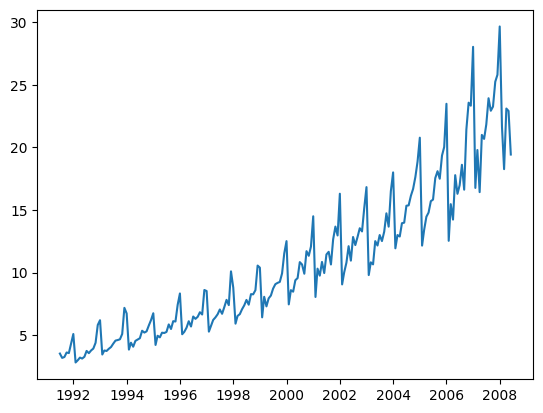

In [5]:
plt.plot(df2.set_index('date'))

In [25]:
#см. model add или мультипликатив
# decompose = sm.tsa.seasonal_decompose(df2.set_index('date'), model='additive', period=16)
# без периода  сезонность правильная
decompose = sm.tsa.seasonal_decompose(df2.set_index('date'), model='multiplicity')


KeyError: "None of ['date'] are in the columns"

In [24]:
decompose.plot()

AttributeError: 'function' object has no attribute 'plot'

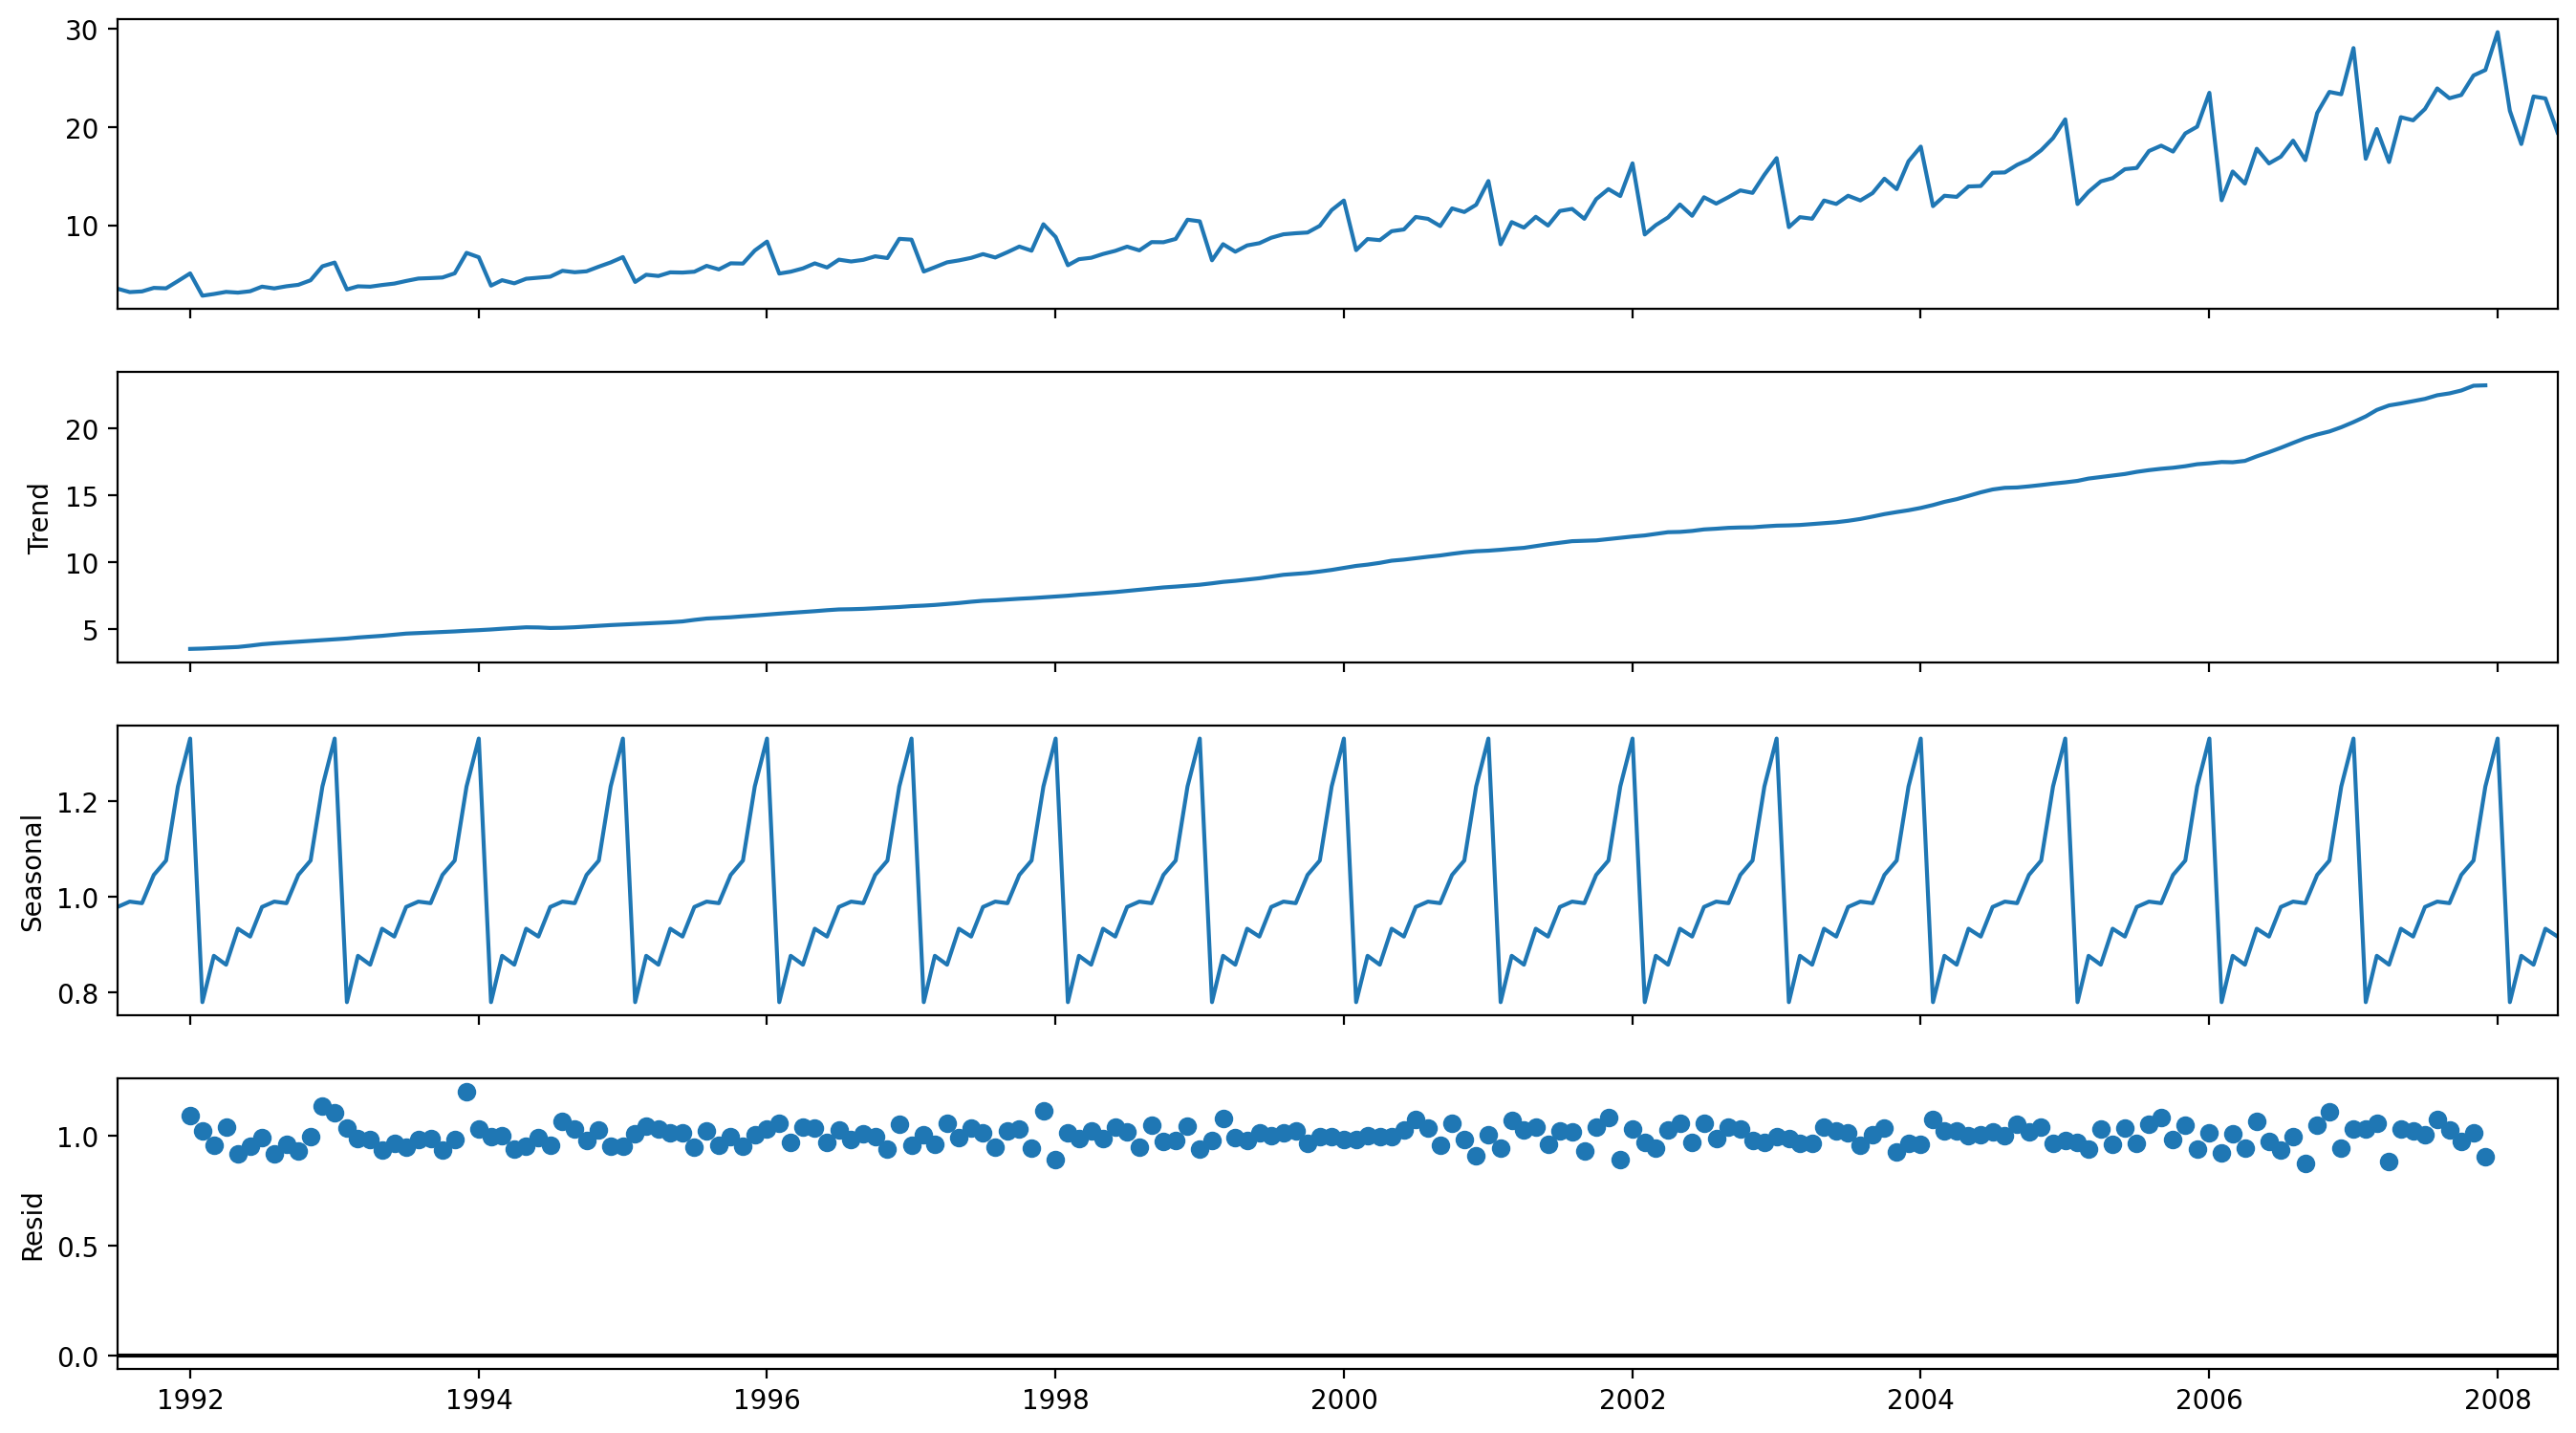

In [95]:
fig = decompose.plot()
fig.set_size_inches(15, 8)
fig.show()

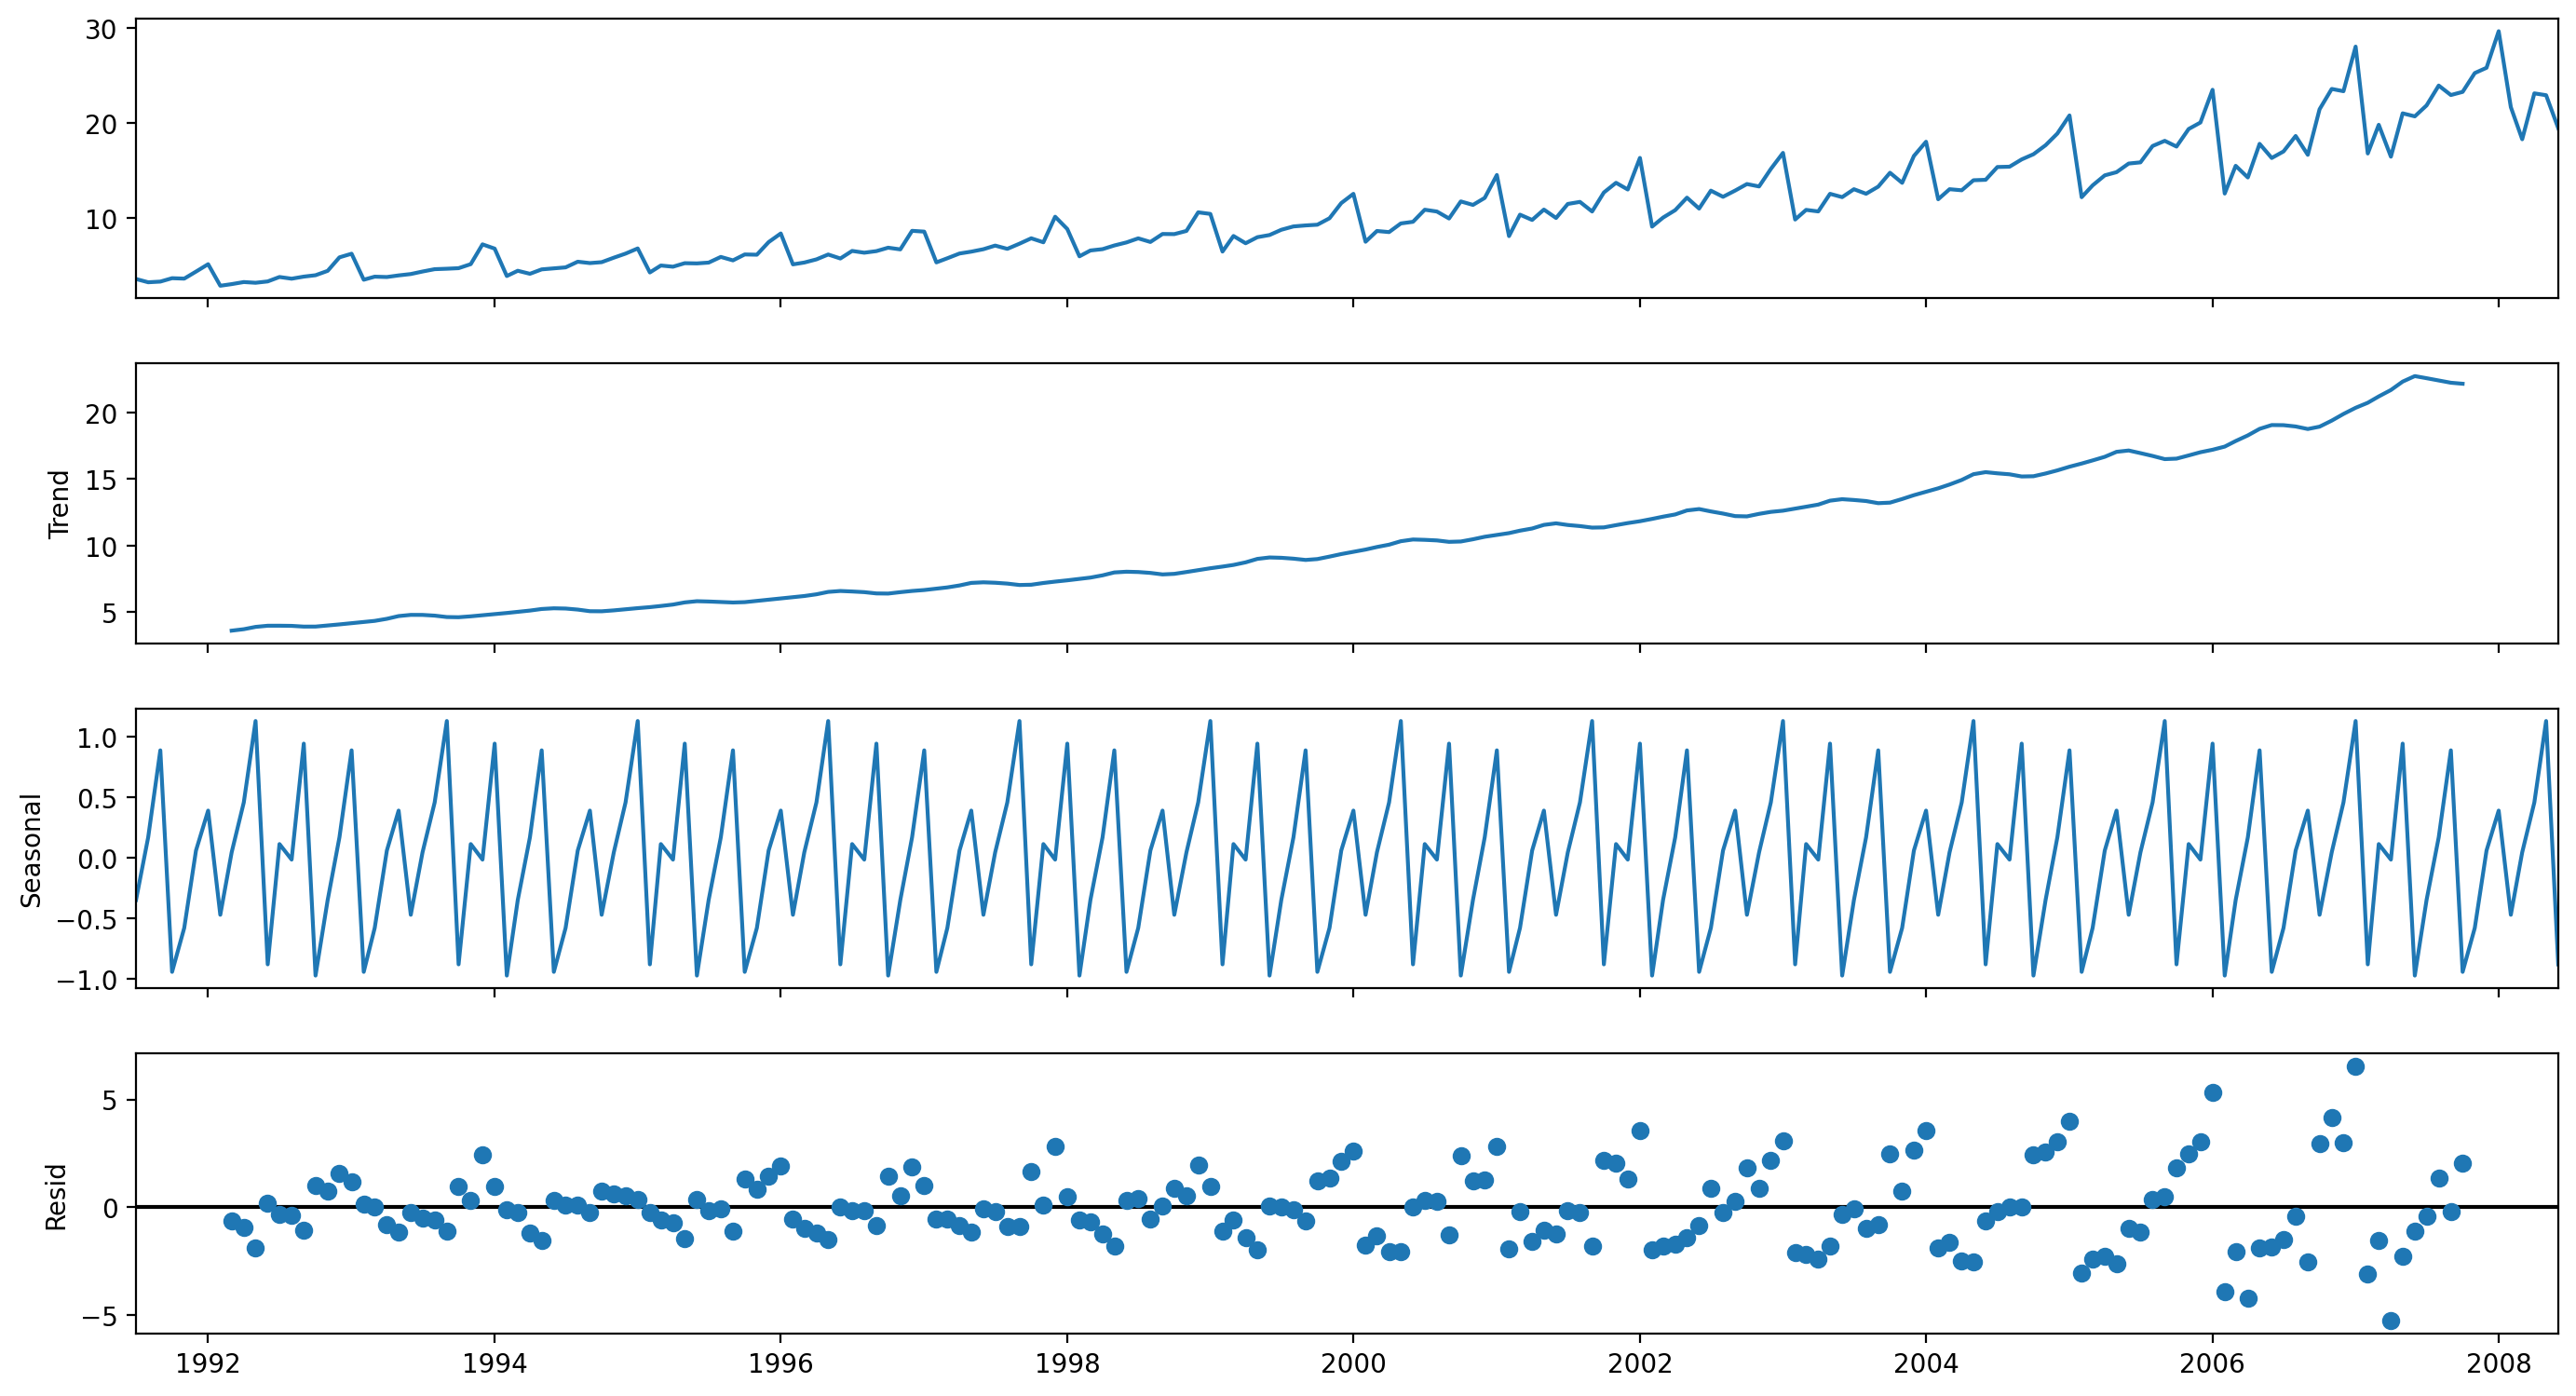

In [ ]:
# модель адд и период неправильный
decompose = sm.tsa.seasonal_decompose(df2.set_index('date'), model='additive', period=16)
fig = decompose.plot()
fig.set_size_inches(15, 8)
fig.show()

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    204 non-null    datetime64[ns]
 1   value   204 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.3 KB


target — столбец, который нужно спрогнозировать;
timestamp — столбец с временными метками;
segment 
Также в выводе данных могут быть столбцы exog и endog. Endog — это целевые ряды, exog — внешние регрессоры

In [6]:
# вставка столбца для одного ряда !!!! или см выше все в 1 ячейке
df2.insert(1, 'segment', 'segment_f')

In [7]:
df2["timestamp"] = df2["date"]

In [8]:
df2["target"] = df2["value"]

In [9]:
df2 = df2.drop('date', axis=1)

In [10]:
df2 = df2.drop('value', axis=1)

In [14]:
df2.head()

,segment,timestamp,target
0,segment_f,1991-07-01,3.526591
1,segment_f,1991-08-01,3.180891
2,segment_f,1991-09-01,3.252221
3,segment_f,1991-10-01,3.611003
4,segment_f,1991-11-01,3.565869


In [ ]:
# !!!! для ETNA обязательно преобразование в ТАйм сериес
dff = TSDataset.to_dataset(df2)


In [16]:
dff.head()

segment,segment_f
feature,target
timestamp,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


In [54]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 204 entries, 1991-07-01 to 2008-06-01
Data columns (total 1 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (segment_f, target)  204 non-null    float64
dtypes: float64(1)
memory usage: 11.3 KB


In [ ]:
dff.describe

<bound method NDFrame.describe of segment             f
feature        target
timestamp            
1991-07-01   3.526591
1991-08-01   3.180891
1991-09-01   3.252221
1991-10-01   3.611003
1991-11-01   3.565869
...               ...
2008-02-01  21.654285
2008-03-01  18.264945
2008-04-01  23.107677
2008-05-01  22.912510
2008-06-01  19.431740

[204 rows x 1 columns]>

In [16]:
#ts1 = TSDataset(dff, freq="D")
ts1 = TSDataset(dff, freq="MS")
ts1.head(5)

segment,segment_f
feature,target
timestamp,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


In [59]:
ts1,

(segment     segment_f
 feature        target
 timestamp            
 1991-07-01   3.526591
 1991-08-01   3.180891
 1991-09-01   3.252221
 1991-10-01   3.611003
 1991-11-01   3.565869
 ...               ...
 2008-02-01  21.654285
 2008-03-01  18.264945
 2008-04-01  23.107677
 2008-05-01  22.912510
 2008-06-01  19.431740
 
 [204 rows x 1 columns],)

In [60]:
ts1.info()

<class 'etna.datasets.TSDataset'>
num_segments: 1
num_exogs: 0
num_regressors: 0
num_known_future: 0
freq: MS
end_timestamp: 2008-06-01 00:00:00
          start_timestamp  length  num_missing
segments                                      
segment_f      1991-07-01     204            0


In [17]:
ts1.describe()

,start_timestamp,end_timestamp,length,num_missing,num_segments,num_exogs,num_regressors,num_known_future,freq
segments,,,,,,,,,
segment_f,1991-07-01,2008-06-01,204,0,1,0,0,0,MS


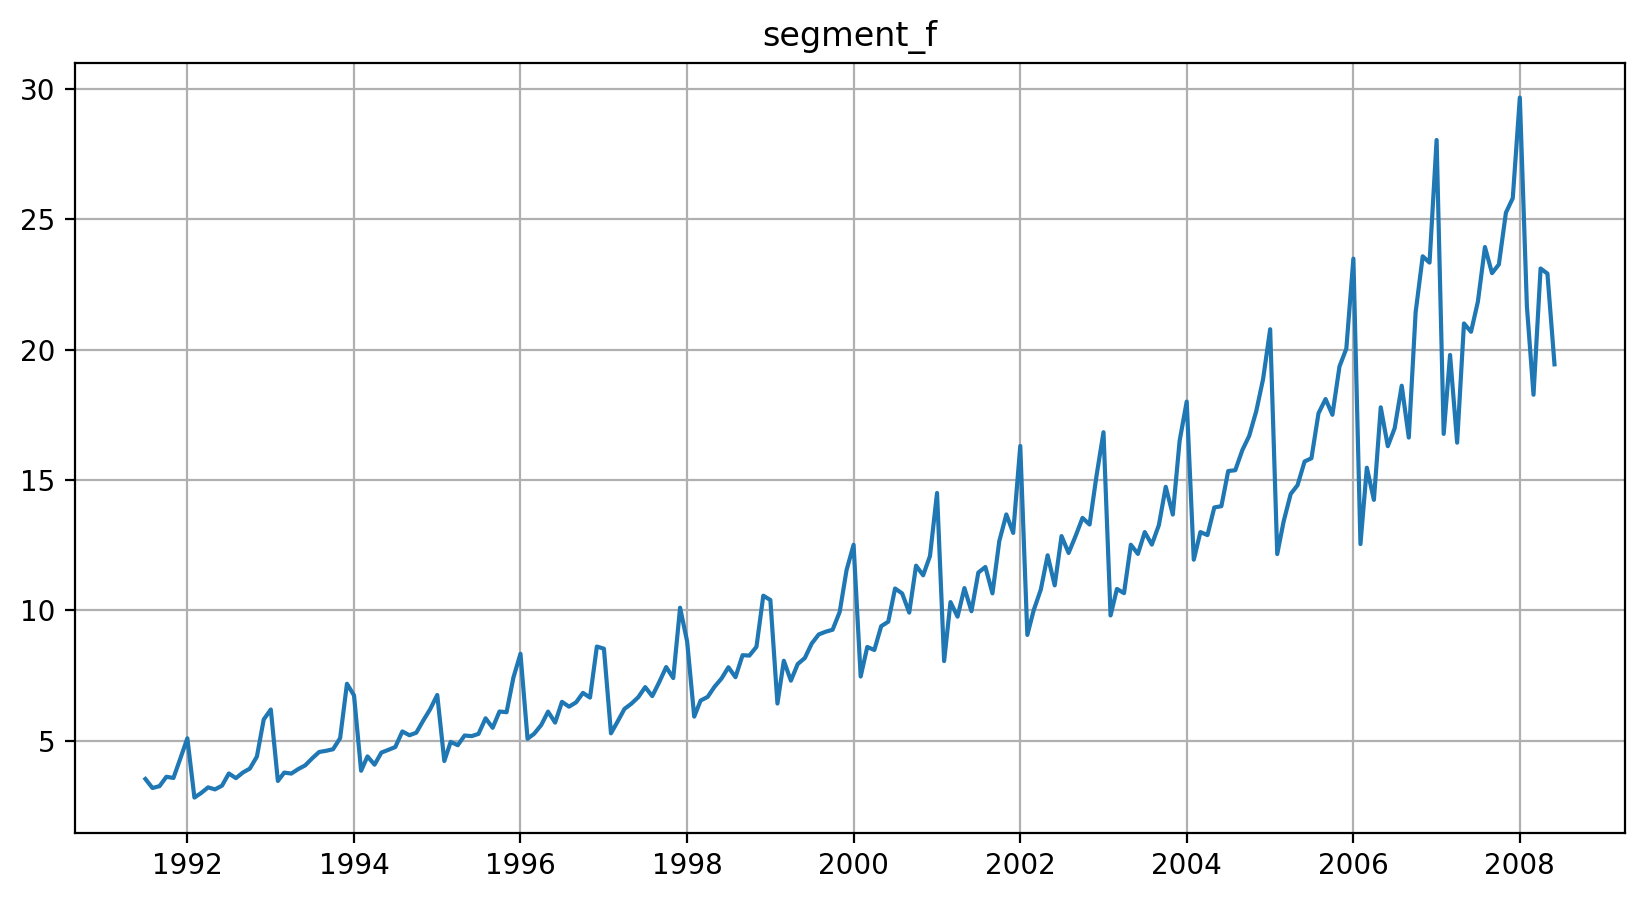

In [19]:
ts1.plot()

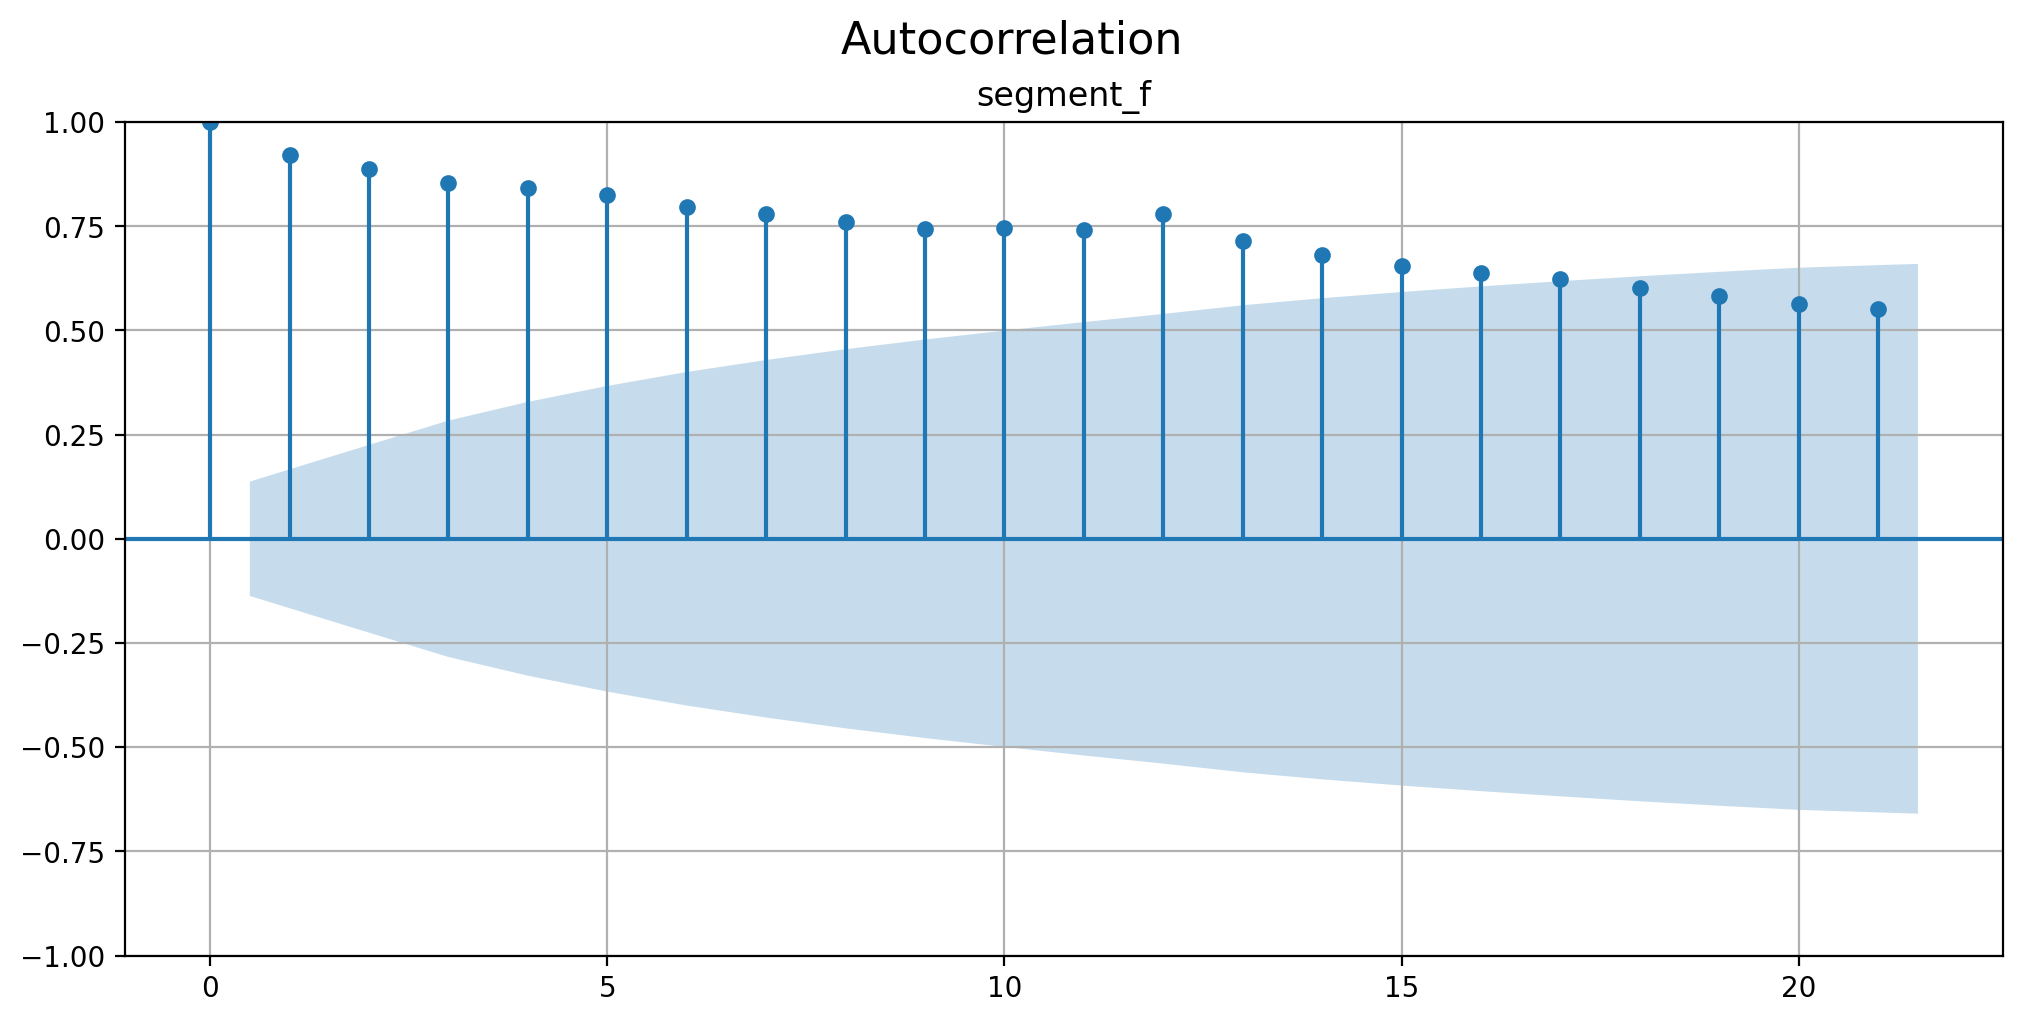

In [ ]:
# автокорреляция по лагам 
# чтобы был 1 график ниж подчеркивание _ = acf_plot
acf_plot(ts1, lags=21)

In [68]:
lags = LagTransform(in_column="target", lags=[5, 20], out_column="lag")
ts1.fit_transform([lags])

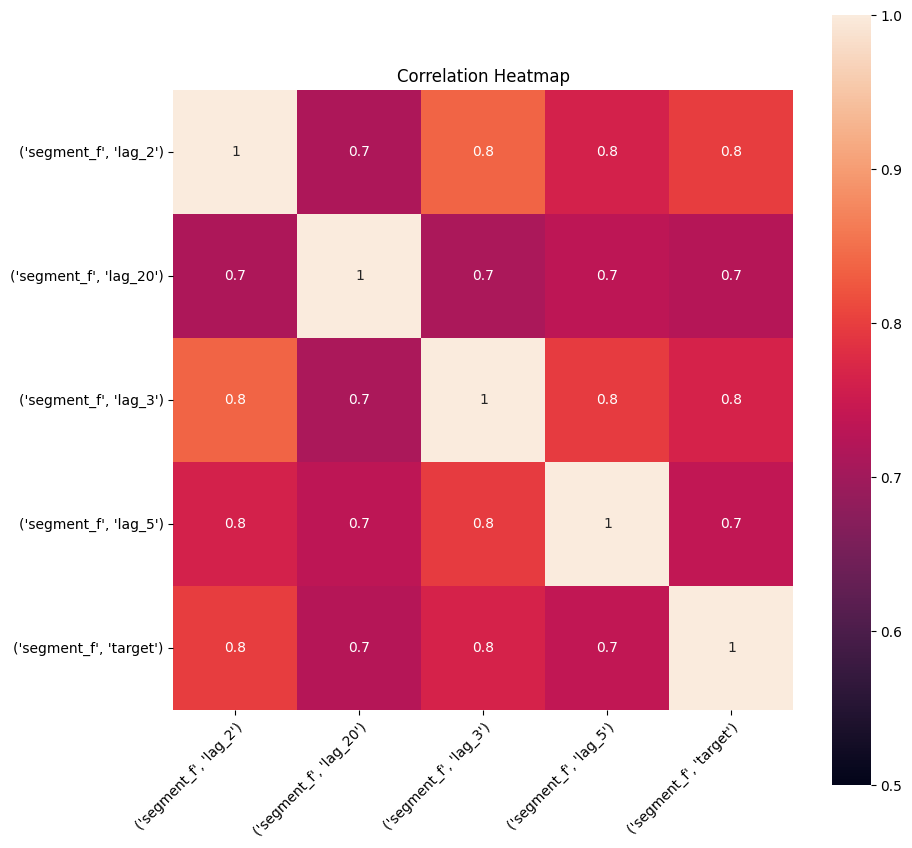

In [70]:
plot_correlation_matrix(ts1, segments=["segment_f"], method="kendall", vmin=0.5, vmax=1)

In [71]:
trends = [
    LinearTrendTransform(in_column="target", poly_degree=1),
    LinearTrendTransform(in_column="target", poly_degree=2)
]

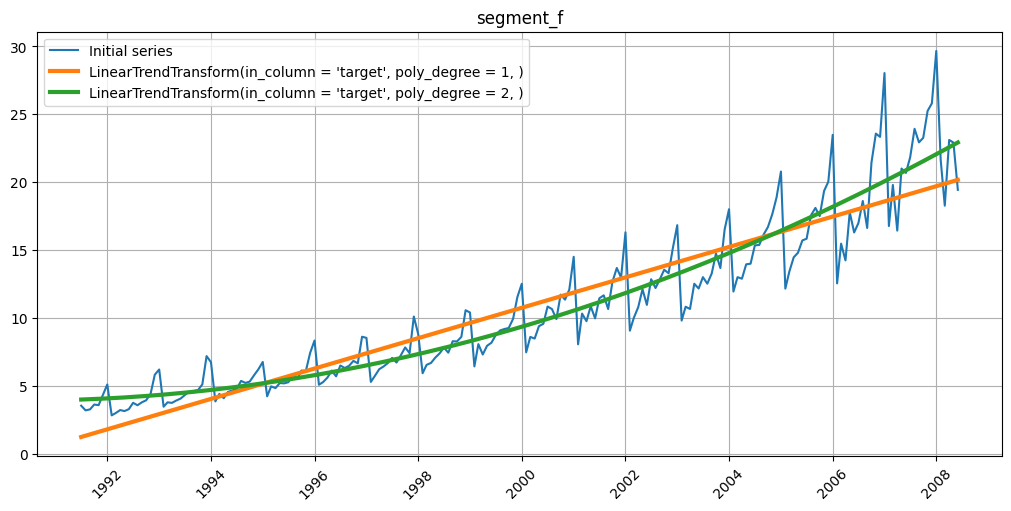

In [73]:
plot_trend(ts1, trend_transform=trends)

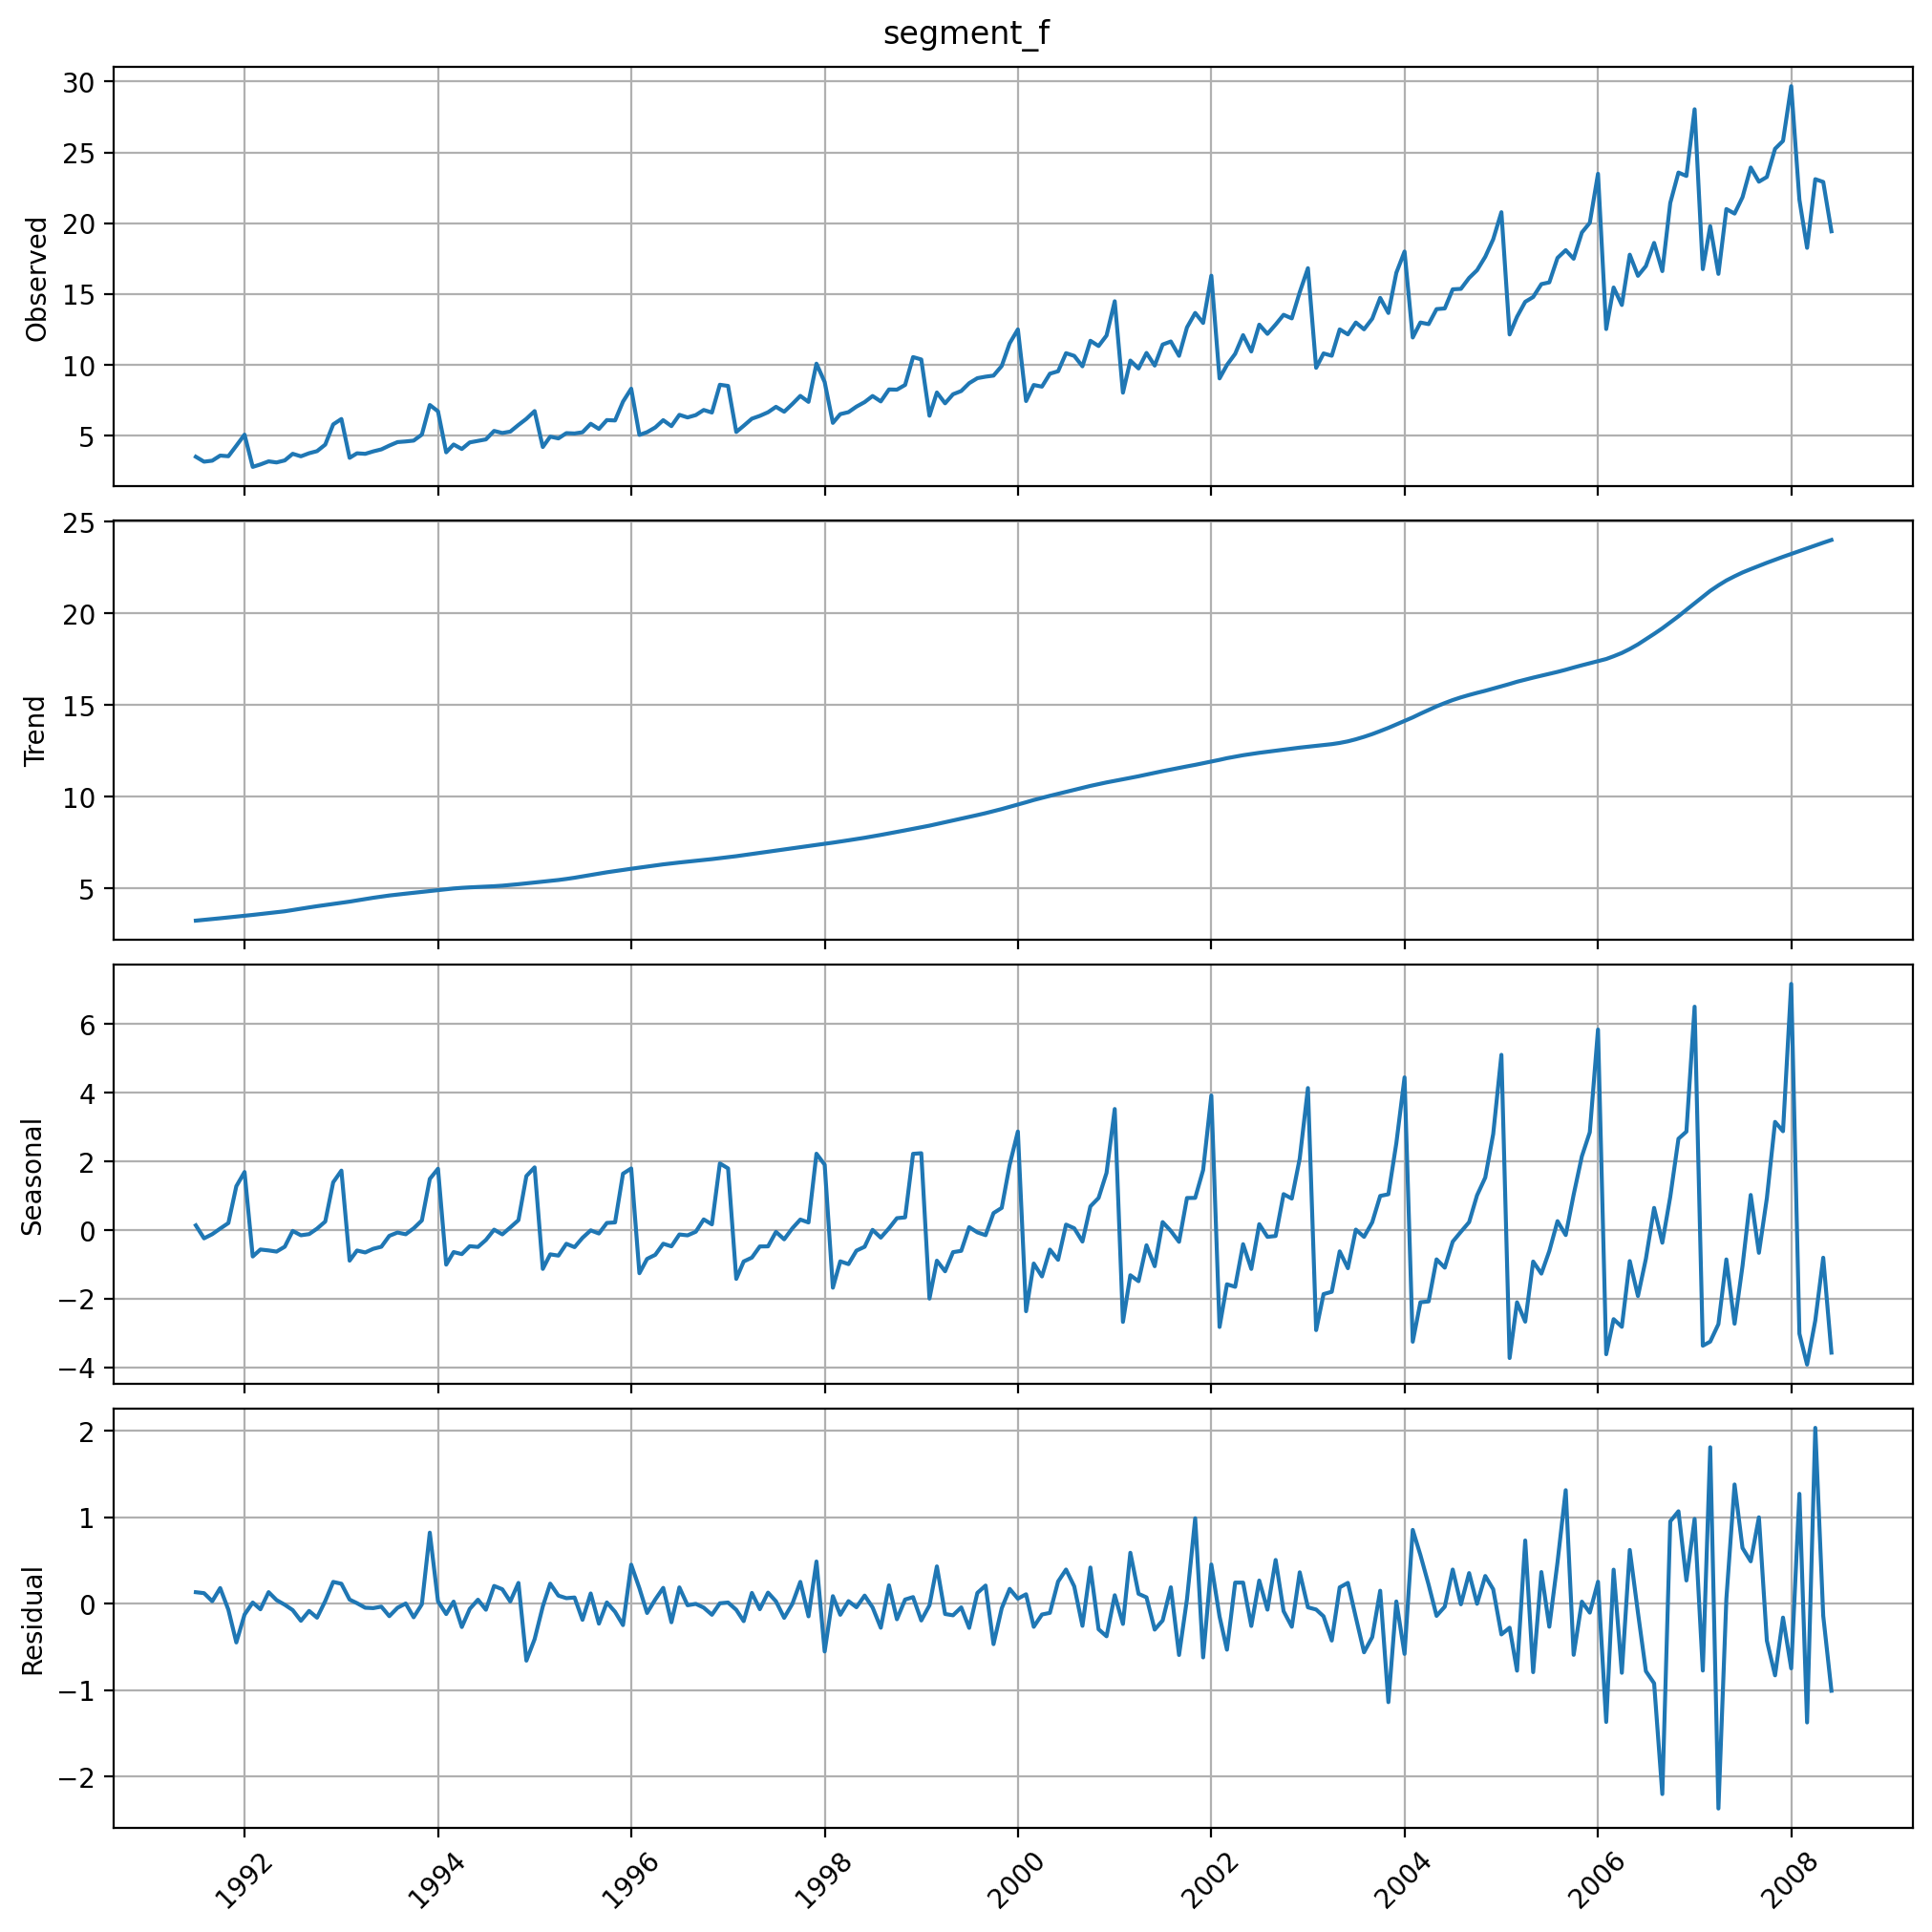

In [26]:
# STL (Seasonal-Trend decomposition using Loess) — 
# метод декомпозиции временных рядов, который 
# позволяет выделить тренд, сезонность и остатки. 
stl_plot(ts=ts1, period=12)

In [32]:
# шум большой 
# используем Бокса-Кокса, возьмем логарифм
STL(np.log(ts1), period = 12).fit().plot()

TypeError: loop of ufunc does not support argument 0 of type TSDataset which has no callable log method

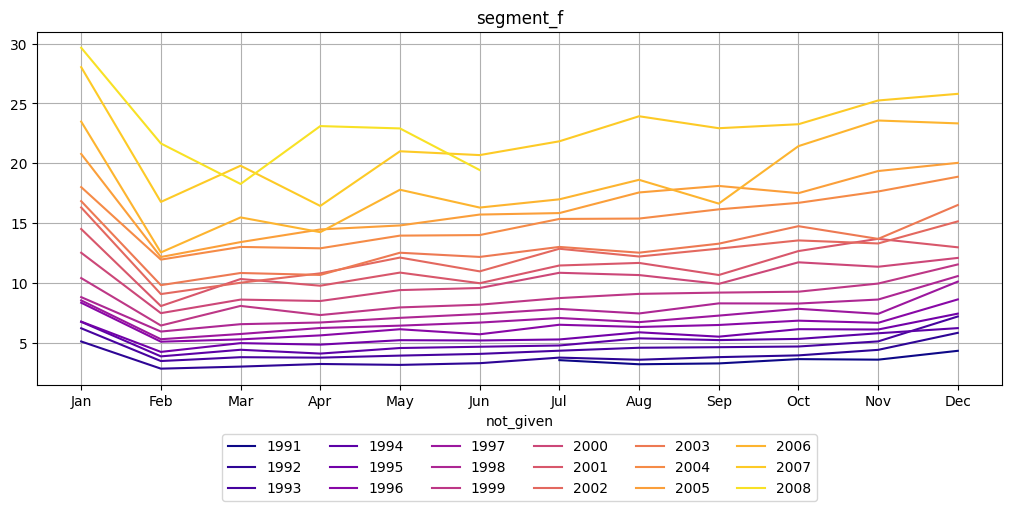

In [78]:
seasonal_plot(ts=ts1, cycle="year")

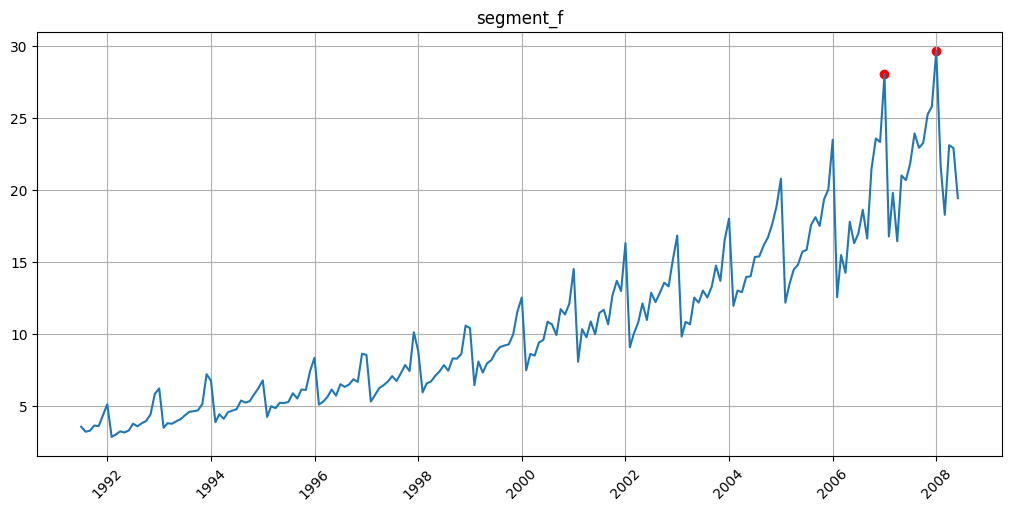

In [79]:
anomaly_dict = get_anomalies_median(ts1, window_size=100)
plot_anomalies(ts1, anomaly_dict)

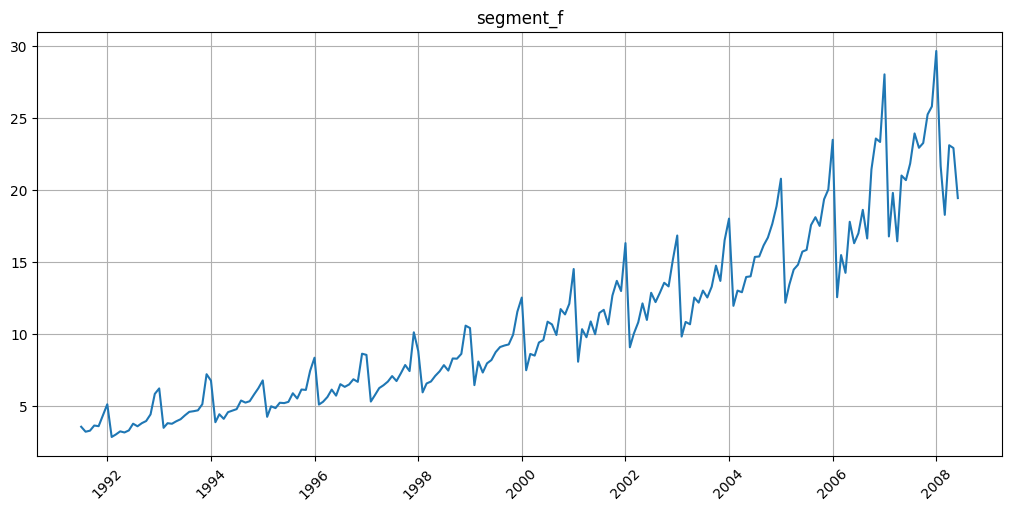

In [81]:
anomaly_dict = get_anomalies_density(ts1, window_size=18, distance_coef=1, n_neighbors=4)
plot_anomalies(ts1, anomaly_dict)

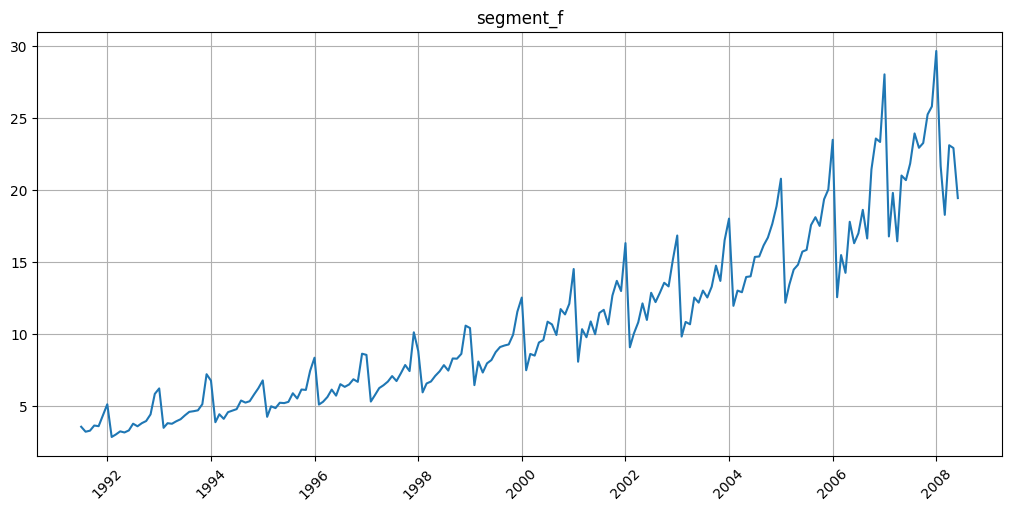

In [82]:
anomaly_dict = get_anomalies_density(ts1)
plot_anomalies(ts1, anomaly_dict)

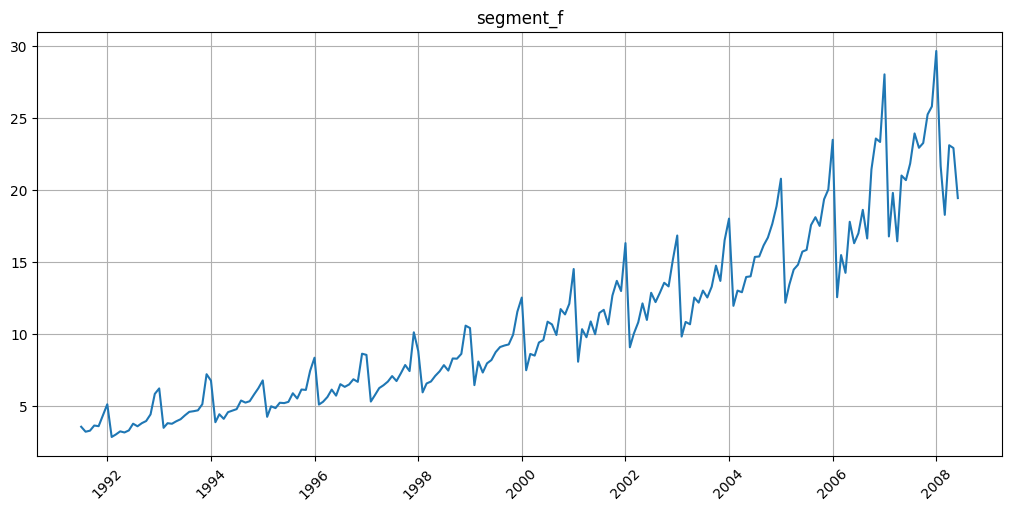

In [83]:
change_points = find_change_points(ts=ts1, in_column="target", change_point_model=Binseg(), pen=1e5)
plot_time_series_with_change_points(ts=ts1, change_points=change_points)

In [85]:
params_bounds = {"n_bkps": [0, 8, 2], "min_size": [1, 10, 3]}
plot_change_points_interactive(
    ts=ts1,
    change_point_model=Binseg,
    model="l2",
    params_bounds=params_bounds,
    model_params=["min_size"],
    predict_params=["n_bkps"],
    figsize=(20, 10),
)

interactive(children=(IntSlider(value=0, continuous_update=False, description='n_bkps', max=8, step=2, style=S…

Прогнозные модели

In [34]:
ts1,

(segment     segment_f
 feature        target
 timestamp            
 1991-07-01   3.526591
 1991-08-01   3.180891
 1991-09-01   3.252221
 1991-10-01   3.611003
 1991-11-01   3.565869
 ...               ...
 2008-02-01  21.654285
 2008-03-01  18.264945
 2008-04-01  23.107677
 2008-05-01  22.912510
 2008-06-01  19.431740
 
 [204 rows x 1 columns],)

In [18]:
# разбиваем набор на обучающую и тестовую выборки с учетом временной структуры
train_ts, test_ts = ts1.train_test_split(train_start='1991-07-01',
                                        train_end='2007-05-01',
                                        test_start='2007-06-01',
                                        test_end='2008-06-01')
                                        

In [36]:
train_ts

segment,segment_f
feature,target
timestamp,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869
...,...
2007-01-01,28.038383
2007-02-01,16.763869


In [38]:
#Модель наивного прогноза
HORIZON = 8
model = NaiveModel(lag=1)
model.fit(train_ts)

future_ts = train_ts.make_future(future_steps=HORIZON, 
                                 tail_steps=model.context_size)
future_ts

segment,segment_f
feature,target
timestamp,
2007-05-01,21.000742
2007-06-01,NaN
2007-07-01,NaN
2007-08-01,NaN
2007-09-01,NaN
2007-10-01,NaN
2007-11-01,NaN
2007-12-01,NaN


In [39]:
forecast_ts = model.forecast(future_ts, 
                             prediction_size=HORIZON)
forecast_ts

segment,segment_f
feature,target
timestamp,
2007-06-01,21.000742
2007-07-01,21.000742
2007-08-01,21.000742
2007-09-01,21.000742
2007-10-01,21.000742
2007-11-01,21.000742
2007-12-01,21.000742
2008-01-01,21.000742


In [40]:
model = NaiveModel(lag=12)
model.fit(train_ts)
future_ts = train_ts.make_future(future_steps=HORIZON, 
                                 tail_steps=model.context_size)
forecast_ts = model.forecast(future_ts, 
                             prediction_size=HORIZON)
forecast_ts

segment,segment_f
feature,target
timestamp,
2007-06-01,16.291602
2007-07-01,16.980282
2007-08-01,18.612189
2007-09-01,16.623343
2007-10-01,21.430241
2007-11-01,23.575517
2007-12-01,23.334206
2008-01-01,28.038383


In [ ]:
smape = SMAPE()
smape(y_true=test_ts, y_pred=forecast_ts)

ValueError: y_true and y_pred have different timestamps

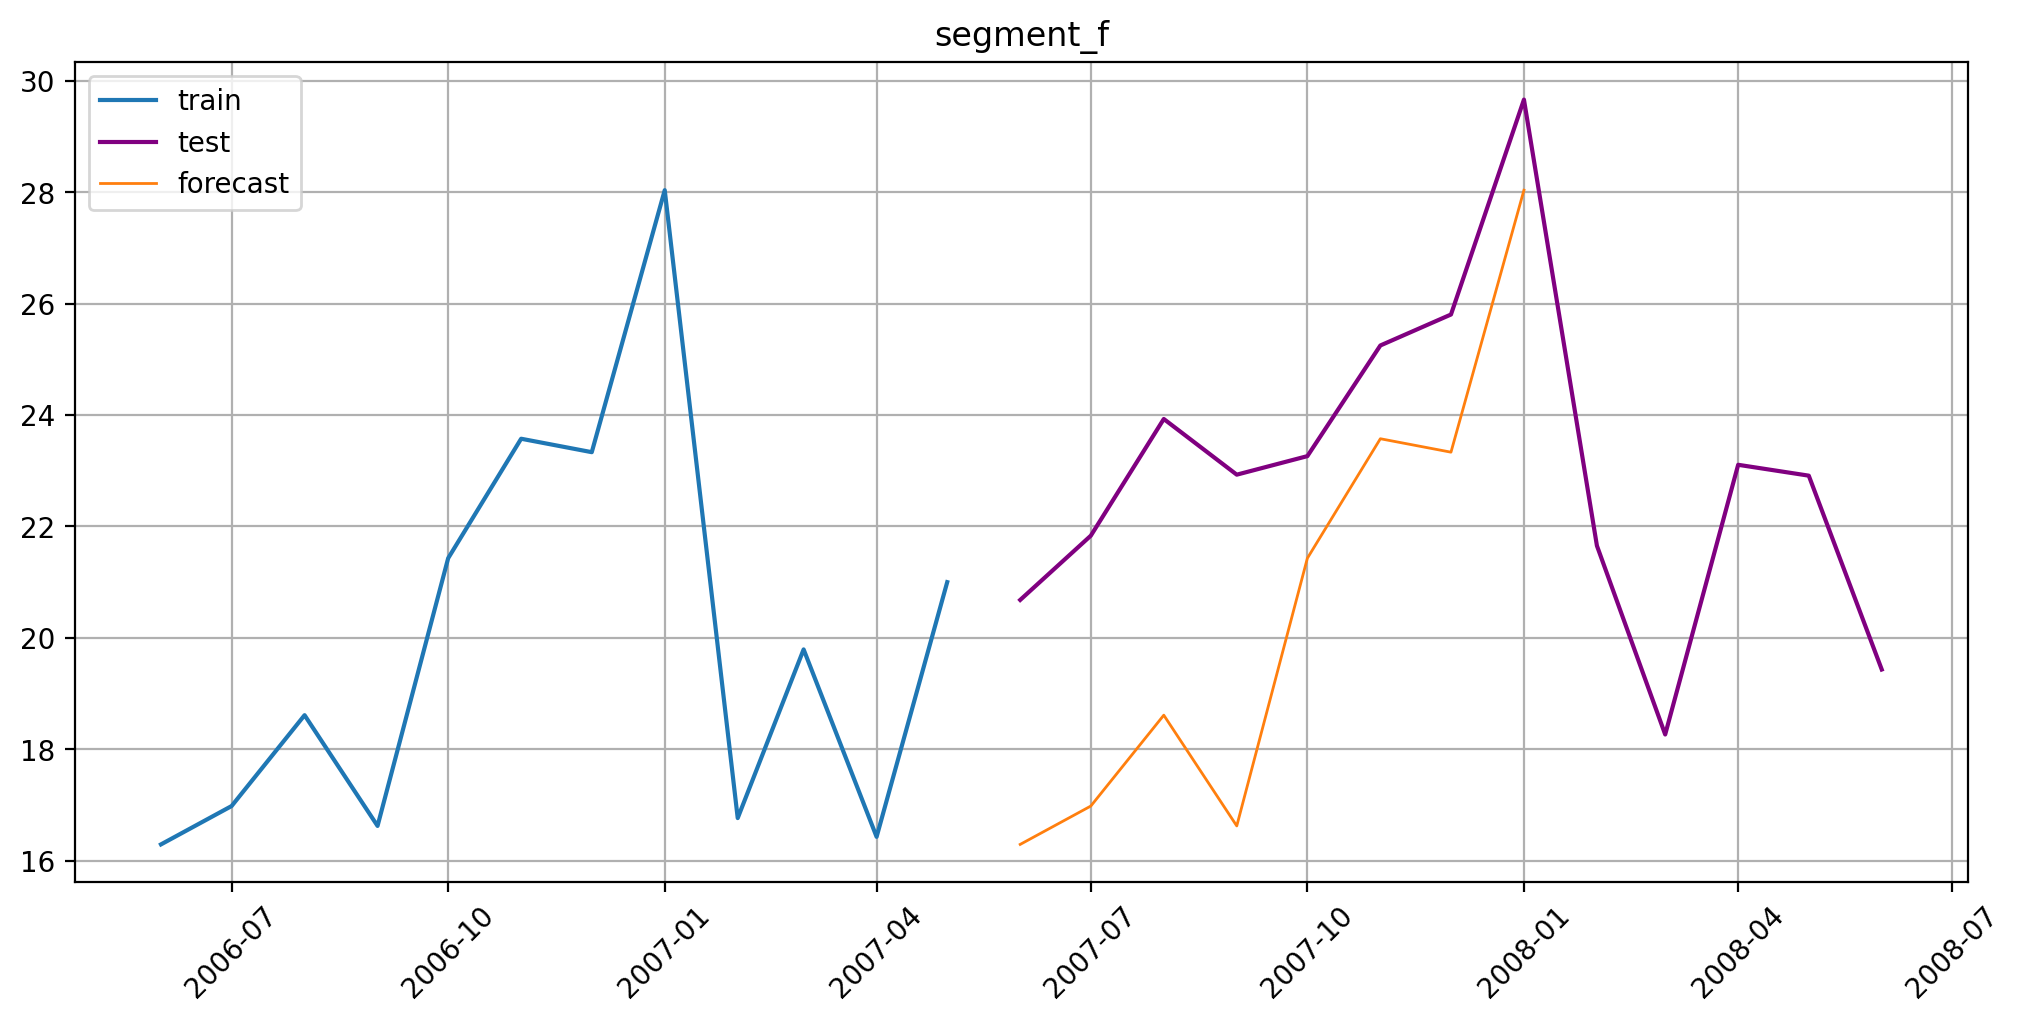

In [42]:
plot_forecast(forecast_ts, test_ts, train_ts, n_train_samples=12)